In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
corr = df.corr(numeric_only=True)

In [153]:
df=pd.read_excel('Processed_Flipdata.xlsx')

In [154]:
df

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999
...,...,...,...,...,...,...,...,...,...,...,...,...
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,79999
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,5998
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,9990
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core",38999


In [155]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [156]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [157]:
df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [158]:
df.columns = df.columns.str.strip()
df.rename(columns={'Prize': 'Price'}, inplace=True)

/tmp/ipykernel_267/1362752690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'Prize': 'Price'}, inplace=True)


In [159]:
df.describe()

,Memory,RAM,Battery_,AI Lens,Mobile Height,Price
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


In [160]:
df.columns

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Price'],
      dtype='object')

In [161]:
df.tail()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Price
536,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,79999
537,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,5998
538,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,9990
539,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core",38999
540,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,15999


**## Missing Values Analysis**

In [162]:
df.isnull().sum()

,0
Model,0
Colour,0
Memory,0
RAM,0
Battery_,0
Rear Camera,0
Front Camera,0
AI Lens,0
Mobile Height,0
Processor_,0


In [163]:
df.duplicated().sum()

np.int64(10)

In [164]:
df.describe()

,Memory,RAM,Battery_,AI Lens,Mobile Height,Price
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


In [165]:
df['Price'].describe()

,Price
count,541.000000
mean,16228.375231
std,10793.588322
min,920.000000
25%,9290.000000
50%,13499.000000
75%,19280.000000
max,80999.000000


In [166]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

**UNIVARIATE ANALYSIS**

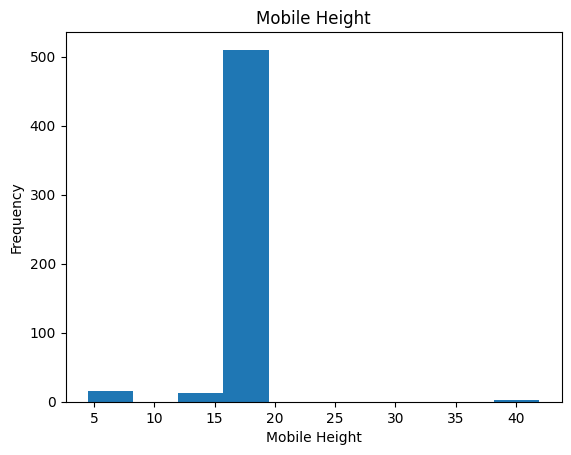

In [167]:
plt.figure()
plt.hist(df['Mobile Height'])
plt.xlabel("Mobile Height")
plt.ylabel("Frequency")
plt.title("Mobile Height")
plt.show()

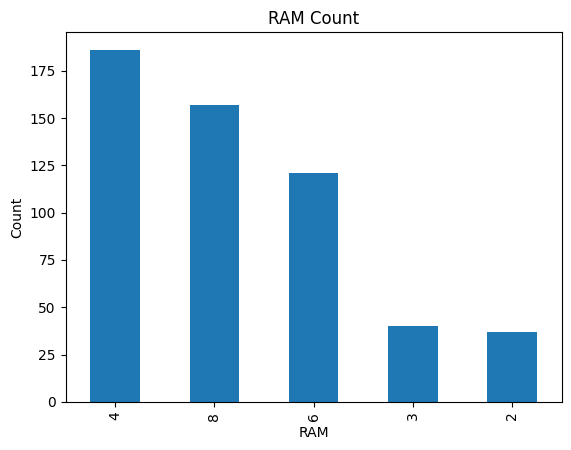

In [168]:
plt.figure()
df['RAM'].value_counts().plot(kind='bar')
plt.xlabel("RAM")
plt.ylabel("Count")
plt.title("RAM Count")
plt.show()

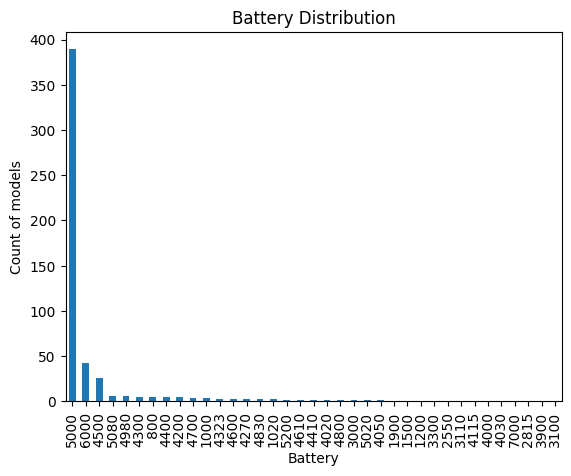

In [169]:
plt.figure()
df['Battery_'].value_counts().plot(kind='bar')
plt.xlabel("Battery")
plt.ylabel("Count of models")
plt.title("Battery Distribution")
plt.show()

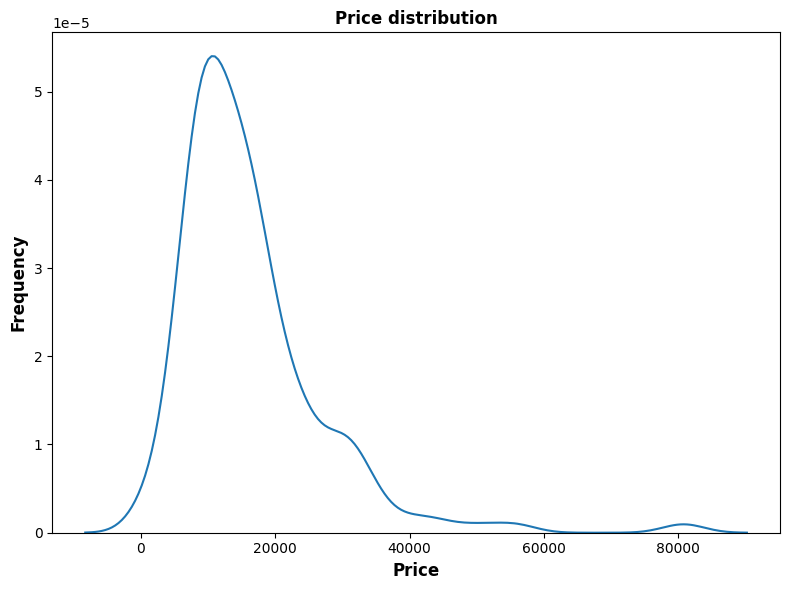

In [170]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x='Price')
plt.title('Price distribution',fontdict={'fontsize':12,'fontweight':'bold'})
plt.xlabel('Price',fontdict={'fontsize':12,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':12,'fontweight':'bold'})
plt.tight_layout()
plt.show()

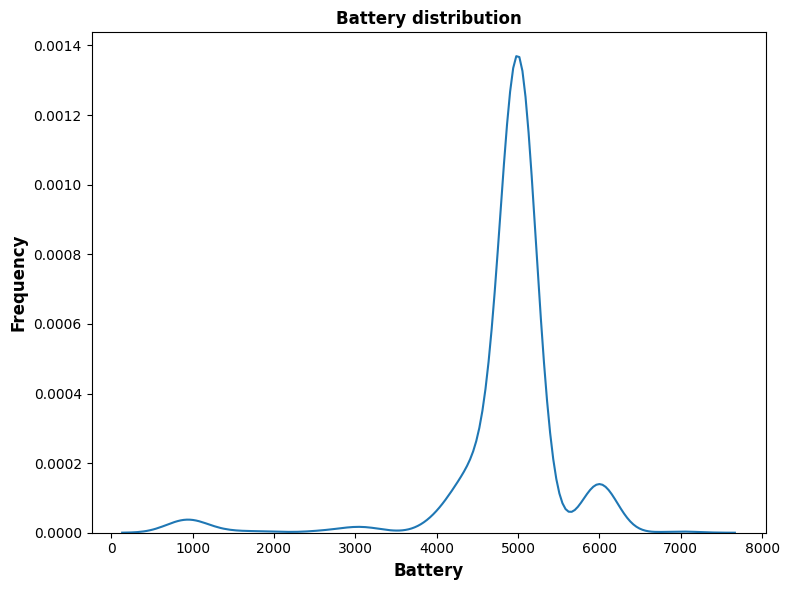

In [171]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x='Battery_')
plt.title('Battery distribution',fontdict={'fontsize':12,'fontweight':'bold'})
plt.xlabel('Battery',fontdict={'fontsize':12,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':12,'fontweight':'bold'})
plt.tight_layout()
plt.show()

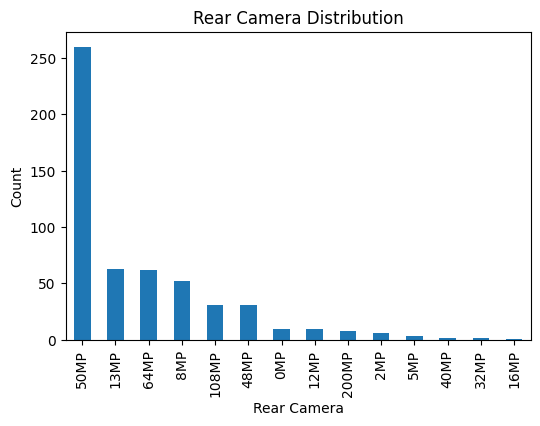

In [172]:
plt.figure(figsize=(6,4))
df['Rear Camera'].value_counts().plot(kind='bar')

plt.xlabel("Rear Camera")
plt.ylabel("Count")
plt.title("Rear Camera Distribution")
plt.show()

**BIVARIATE ANALYSIS**

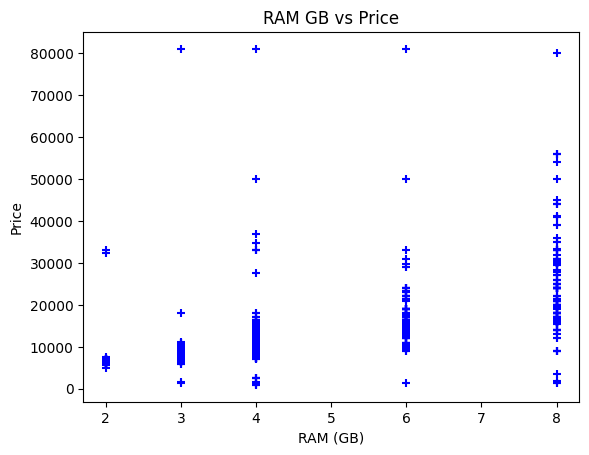

In [173]:
%matplotlib inline
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.title ("RAM GB vs Price")
plt.scatter(df['RAM'],df['Price'], color='blue', marker='+')

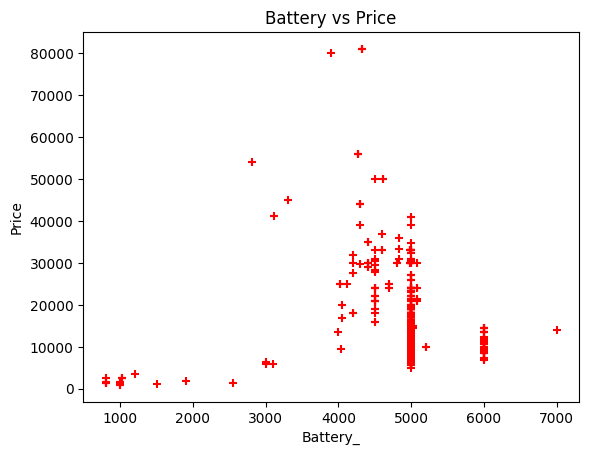

In [174]:
%matplotlib inline
plt.xlabel('Battery_')
plt.ylabel('Price')
plt.title ("Battery vs Price")
plt.scatter(df['Battery_'],df['Price'], color='red', marker='+')

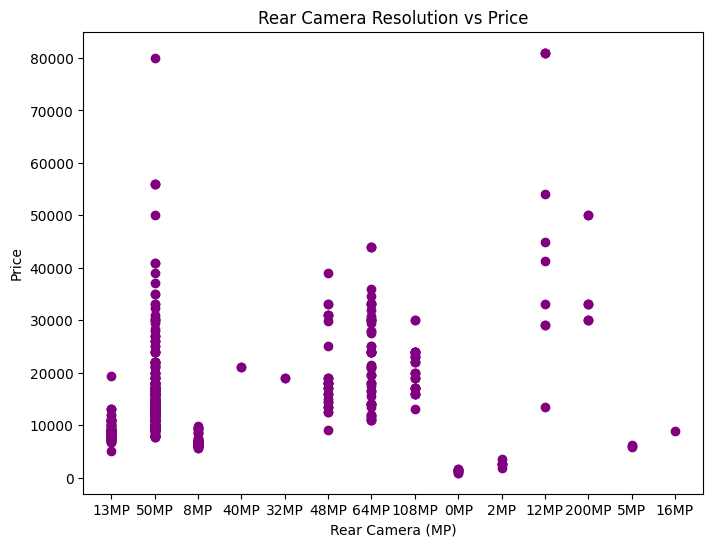

In [175]:
plt.figure(figsize=(8,6))
plt.scatter(df['Rear Camera'], df['Price'], color='purple')
plt.xlabel("Rear Camera (MP)")
plt.ylabel("Price")
plt.title("Rear Camera Resolution vs Price")
plt.show()


**MULTIVARIATE ANALYSIS**

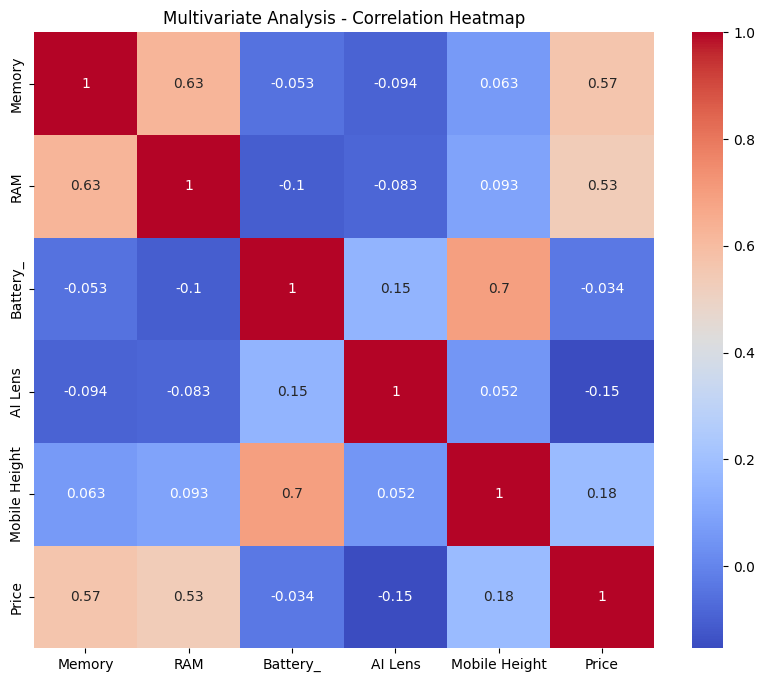

In [176]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Multivariate Analysis - Correlation Heatmap")
plt.show()

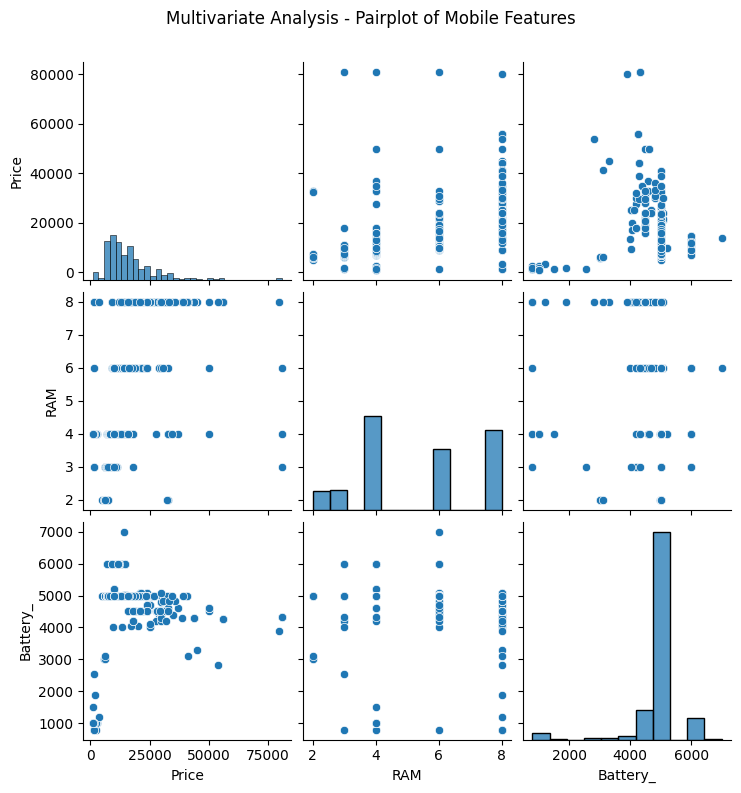

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['Price','RAM','Battery_','Rear Camera']])

plt.suptitle("Multivariate Analysis - Pairplot of Mobile Features", y=1.05)
plt.show()